[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Quantitative-Research-Methods/blob/main/Advanced/Lab_Notebooks/advanced_02_shapley_lab.ipynb)

*This notebook runs on Colab as-is. The badge link above and the `GITHUB_RAW` line in the setup cell already point to this repository, so everything installs and loads automatically.*

# Advanced Module A2 — Explainable AI with Shapley Values
## Lab: the value function, exact Shapley by enumeration, Monte-Carlo sampling, local and global pictures, pitfalls

**Course:** Quantitative Research Methods
**Instructor:** Prof. Dr. Christoph Weisser, HSBI
**Source:** James, Witten, Hastie, Tibshirani & Taylor (2023), *An Introduction to Statistical Learning, with Applications in Python*, Springer. Companion code at [statlearning.com](https://www.statlearning.com). This advanced module extends the book with Shapley-value explanations (Shapley 1953; Lundberg & Lee 2017).

**Goal.** Fit a gradient-boosted model on `Hitters` and explain its predictions from scratch: build the marginal value function on a background sample; enumerate all $2^6$ coalitions for exact Shapley values and verify the efficiency axiom to machine precision; approximate them by permutation sampling and watch the $1/\sqrt{m}$ convergence; read local waterfalls, global importance and dependence plots; and run straight into the two classic pitfalls — correlated features and retrain instability.

## Setup

Run this cell once. The `ISLP` package can be installed with `pip install ISLP`. As an alternative, the same data sets are available as CSVs in the workspace's `ALL CSV FILES - 2nd Edition` folder.


> **Google Colab:** this notebook also runs on Colab out of the box — the setup cell below installs any missing packages and downloads the data automatically.

In [1]:
# --- Setup: runs locally AND on Google Colab --------------------------------
# Silence only the spurious 'encountered in matmul' RuntimeWarnings that the macOS
# Accelerate BLAS emits; real warnings (deprecations, model caveats) stay visible.
import warnings
warnings.filterwarnings('ignore', message='.*encountered in matmul', category=RuntimeWarning)
import importlib.util, os, subprocess, sys

IN_COLAB = 'google.colab' in sys.modules

def _ensure(pkg, import_name=None):
    """pip-install pkg (quietly) if its import is missing."""
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)

if IN_COLAB:  # Colab ships numpy/pandas/sklearn/statsmodels; add course extras
    for _pkg, _imp in [('ISLP', 'ISLP')]:
        _ensure(_pkg, _imp)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2024)
plt.rcParams['figure.dpi'] = 110

try:
    from ISLP import load_data
    HAVE_ISLP = True
except ImportError:
    HAVE_ISLP = False
    print('ISLP not installed; using CSV / URL fallbacks.')

# Local CSV location (repo layout first, then legacy paths, then a data/ cache).
_CANDIDATES = ['../ALL CSV FILES - 2nd Edition',
               'ALL CSV FILES - 2nd Edition',
               '../../ALL CSV FILES - 2nd Edition', 'data']
CSV = next((p for p in _CANDIDATES if os.path.isdir(p)), 'data')

# GITHUB_RAW lets a fresh Colab runtime fetch any
# CSV that is neither in ISLP nor already local (spaces in the folder -> %20).
GITHUB_RAW = ('https://raw.githubusercontent.com/ChrisW09/Quantitative-Research-Methods/main/'
              'ALL%20CSV%20FILES%20-%202nd%20Edition')

# The four datasets NOT in the ISLP package -> load from the book's official
# site so the notebook works on a fresh Colab even before the repo is published.
KNOWN_URLS = {
    'Advertising': 'https://www.statlearning.com/s/Advertising.csv',
    'Heart':       'https://www.statlearning.com/s/Heart.csv',
    'Income1':     'https://www.statlearning.com/s/Income1.csv',
    'Income2':     'https://www.statlearning.com/s/Income2.csv',
}

def load(name, **read_csv_kwargs):
    """Load a course dataset. Order: ISLP package -> R datasets -> local CSV
    -> official book URL -> your GitHub repo. Works locally and on Colab."""
    if HAVE_ISLP:
        try:
            return load_data(name)
        except Exception:
            pass
    if name == 'USArrests':                       # classic R dataset, not in ISLP
        try:
            import statsmodels.api as sm
            return sm.datasets.get_rdataset('USArrests', 'datasets').data
        except Exception:
            pass
    path = f'{CSV}/{name}.csv'
    if os.path.exists(path):                      # running from the repo (local)
        return pd.read_csv(path, **read_csv_kwargs)
    remotes = ([KNOWN_URLS[name]] if name in KNOWN_URLS else []) + [f'{GITHUB_RAW}/{name}.csv']
    for url in remotes:                           # fresh Colab: stream over https
        try:
            return pd.read_csv(url, **read_csv_kwargs)
        except Exception:
            continue
    raise FileNotFoundError(
        f"Could not load {name!r}. Put the CSV in '{CSV}/' or check your connection for the GITHUB_RAW fallback.")


ISLP not installed; using CSV / URL fallbacks.


## 1. Data and model

The testbed of the deck: `Hitters` — 322 baseball players from the 1986/87 season, 59 missing salaries dropped, $n = 263$. Target: $\log(\texttt{Salary})$ (salaries in \$1,000, range 67.5–2,460 — the log tames the right tail). Six features, small enough for *exact* $2^6 = 64$-coalition Shapley values.

In [2]:
from sklearn.ensemble import GradientBoostingRegressor

Hitters = load('Hitters').dropna().reset_index(drop=True)
FEATS = ['Years', 'CHits', 'CRBI', 'Walks', 'Hits', 'PutOuts']
p = len(FEATS)
X = Hitters[FEATS].to_numpy(float)               # (263, 6)
y = np.log(Hitters['Salary'].to_numpy())         # log $1000s

f = GradientBoostingRegressor(random_state=2024).fit(X, y)
print(f'n = {len(X)},  train R^2 = {f.score(X, y):.3f}')

i_star = 188                                     # the 24-season career-hits record holder
x_star = X[i_star]
print('x* =', dict(zip(FEATS, x_star.astype(int))))
print(f'actual salary ${Hitters["Salary"][i_star]:.0f}k,  f(x*) = {f.predict(x_star.reshape(1, -1))[0]:.4f} log-$'
      f'  (= ${np.exp(f.predict(x_star.reshape(1, -1))[0]):.0f}k)')

n = 263,  train R^2 = 0.965
x* = {'Years': np.int64(24), 'CHits': np.int64(4256), 'CRBI': np.int64(1314), 'Walks': np.int64(30), 'Hits': np.int64(52), 'PutOuts': np.int64(523)}
actual salary $750k,  f(x*) = 6.6102 log-$  (= $743k)


**Reading the output.** Training $R^2 = 0.965$ — an accurate model nobody can read. Row 188 is our running example: a 24-season veteran holding the career-hits record (`CHits` $= 4256$), actual 1987 salary \$750k, model prediction $f(x^\ast) = 6.610$ log-dollars $\approx \$743$k. The question the rest of the notebook answers: *which features account for that prediction?*

## 2. The value function

Features are players; a coalition $S$ means "these feature values are *known* to be $x_S$". The marginal (interventional) value function pins the known features and draws the rest from a **background sample**:

$$v_x(S) = \frac{1}{B}\sum_{b=1}^{B} f\bigl(x_S,\, x^{(b)}_{\bar S}\bigr) - \varphi_0, \qquad \varphi_0 = E[f(X)].$$

In [3]:
rng = np.random.default_rng(2024)                # house seed
bg = X[rng.choice(len(X), 100, replace=False)]   # background sample, B = 100
B = len(bg)
base = f.predict(bg).mean()                      # phi_0 = E[f]

def v(S, x):
    """Marginal value function: pin the features in S at x's values."""
    Z = bg.copy()
    if S:
        Z[:, list(S)] = x[list(S)]
    return f.predict(Z).mean() - base

fx = f.predict(x_star.reshape(1, -1))[0]
print(f'baseline phi_0 = {base:.4f} log-$  (= ${np.exp(base):.0f}k)')
print(f'v(empty)  = {v((), x_star):.4f}          (knowing nothing: 0 by construction)')
print(f'v(full)   = {v(tuple(range(p)), x_star):.4f}   vs   f(x*) - phi_0 = {fx - base:.4f}')

baseline phi_0 = 5.8538 log-$  (= $349k)
v(empty)  = 0.0000          (knowing nothing: 0 by construction)
v(full)   = 0.7564   vs   f(x*) - phi_0 = 0.7564


**Reading the output.** The two anchors of the game: $v_x(\varnothing) = 0$ (knowing nothing gives the average prediction, $\varphi_0 = 5.854 \approx \$349$k) and $v_x(\mathcal P) = f(x^\ast) - \varphi_0 = 0.756$ (knowing everything gives *this* prediction). Efficiency will force the six attributions to share out exactly that $0.756$.

## 3. Exact Shapley by enumeration

The Shapley value with subset weights $w(S) = |S|!\,(p-|S|-1)!/p!$ — for $p = 6$, a sum over all $2^6 = 64$ coalitions. We time it, so the $2^p$ cost is measured on your own clock, not asserted.

In [4]:
import itertools, time
from math import factorial

w = {s: factorial(s) * factorial(p - s - 1) / factorial(p) for s in range(p)}

def exact_shapley(x):
    """Exact Shapley values by enumeration over all 2^p coalitions."""
    phi = np.zeros(p)
    for j in range(p):                           # one player at a time
        rest = [k for k in range(p) if k != j]
        for r in range(p):                       # coalition sizes 0..p-1
            for S in itertools.combinations(rest, r):
                phi[j] += w[r] * (v(S + (j,), x) - v(S, x))
    return phi

t0 = time.time()
phi_star = exact_shapley(x_star)
t1 = time.time()
print(pd.Series(phi_star, index=FEATS).round(4).to_string())
print(f'\nefficiency:  sum phi_j = {phi_star.sum():.4f}   f(x*) - phi_0 = {fx - base:.4f}')
print(f'wall time for one instance: {t1 - t0:.2f}s  '
      f'({2**p} coalitions x {B} background rows per v-call)')

Years     -0.5245
CHits      0.5626
CRBI       0.5474
Walks     -0.0452
Hits      -0.1084
PutOuts    0.3244

efficiency:  sum phi_j = 0.7564   f(x*) - phi_0 = 0.7564
wall time for one instance: 0.05s  (64 coalitions x 100 background rows per v-call)


**Reading the output.** The career totals push the salary up (`CHits` $+0.563$, `CRBI` $+0.547$), the 24 seasons push it *down* ($-0.525$ — given those totals, more seasons mean less production per season), and the six numbers sum to $0.7564 = f(x^\ast) - \varphi_0$ **exactly**. That is the efficiency axiom, and it is what no rival attribution method (gradients, single-feature ablations) gives you for free.

In [5]:
# Efficiency across ALL 263 players — vectorised over instances so it takes
# seconds, not minutes: one predict() call per coalition for every player at once.
def coalition_values(Xv):
    """v_i(S) for every instance i and every coalition S."""
    m = len(Xv); vals = {}
    for r in range(p + 1):
        for S in itertools.combinations(range(p), r):
            Z = np.repeat(bg[None, :, :], m, axis=0)          # (m, B, p)
            if S:
                Z[:, :, S] = Xv[:, None, S]
            vals[S] = f.predict(Z.reshape(m * B, p)).reshape(m, B).mean(axis=1)
    return vals

def exact_shapley_all(Xv):
    vals = coalition_values(Xv)
    phi = np.zeros((len(Xv), p))
    for j in range(p):
        others = [k for k in range(p) if k != j]
        for r in range(p):
            for S in itertools.combinations(others, r):
                Sj = tuple(sorted(S + (j,)))
                phi[:, j] += w[r] * (vals[Sj] - vals[S])
    return phi

PHI = exact_shapley_all(X)                       # (263, 6): one explanation per player
resid = np.abs(PHI.sum(axis=1) - (f.predict(X) - base)).max()
print(f'largest efficiency violation across all 263 players: {resid:.1e}')

largest efficiency violation across all 263 players: 4.4e-15


**Reading the output.** $4.4 \times 10^{-15}$ — floating-point noise. Validation teams re-run exactly this check on sampled instances: if reported attributions do not reproduce $f(x) - \varphi_0$ to numerical precision, the explanation pipeline (wrong background, stale model version) is flagged before the numbers reach a customer letter.

## 4. Monte-Carlo permutation sampling

Exact enumeration doubles with every feature — $2^{20} \approx 10^6$ coalitions at $p = 20$. Permutation sampling (Štrumbelj & Kononenko, 2014) instead draws $m$ random arrival orders; each feature is awarded the change in $v_x$ it causes on arrival. Unbiased, with error $\propto 1/\sqrt m$, at cost $m \cdot p$ value-function calls — independent of $2^p$.

In [6]:
def mc_shapley(x, m, rng):
    """Permutation-sampling estimate of all p Shapley values."""
    est = np.zeros(p)
    for _ in range(m):                           # m random arrival orders
        perm = rng.permutation(p)                # e.g. [3 0 5 1 4 2]
        S, v_prev = [], 0.0                      # empty room: v = 0
        for j in perm:                           # features walk in
            v_new = v(tuple(S) + (int(j),), x)   # value after j joins
            est[j] += v_new - v_prev             # j's marginal contribution
            v_prev = v_new                       # room now includes j
            S.append(int(j))
    return est / m                               # average over orders

rng = np.random.default_rng(2024)                # fresh seeded generator
est = mc_shapley(x_star, 100, rng)               # m = 100 orders
tab = pd.DataFrame({'exact': phi_star, 'mc (m=100)': est,
                    'abs error': np.abs(est - phi_star)}, index=FEATS)
print(tab.round(4).to_string())
print(f'\nmean abs error {np.abs(est - phi_star).mean():.3f},'
      f'  max {np.abs(est - phi_star).max():.3f}')

          exact  mc (m=100)  abs error
Years   -0.5245     -0.5164     0.0081
CHits    0.5626      0.5408     0.0218
CRBI     0.5474      0.5741     0.0267
Walks   -0.0452     -0.0496     0.0044
Hits    -0.1084     -0.1071     0.0014
PutOuts  0.3244      0.3145     0.0099

mean abs error 0.012,  max 0.027


m =   10   mean abs error = 0.0303
m =   25   mean abs error = 0.0153


m =   50   mean abs error = 0.0111


m =  100   mean abs error = 0.0079


m =  200   mean abs error = 0.0047


m =  400   mean abs error = 0.0035


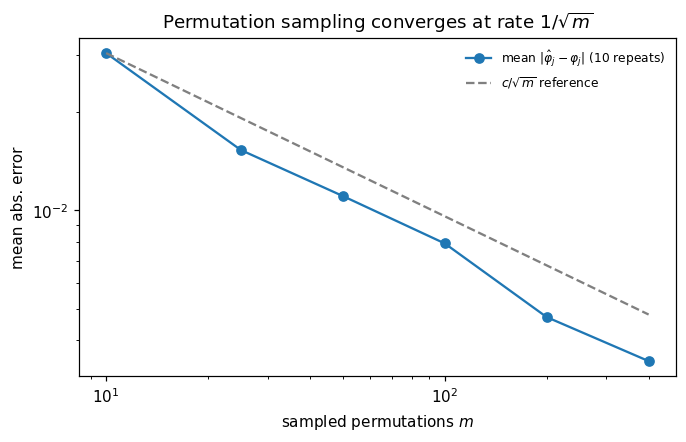

In [7]:
# Convergence study: mean absolute error over 10 repeats at each m.
# (Same algorithm, but each order's p value-function calls are batched into a
# single predict() so the study runs in seconds; the rng draws are identical.)
def mc_shapley_fast(x, m, rng):
    est = np.zeros(p)
    for _ in range(m):
        perm = rng.permutation(p)
        Z = np.repeat(bg[None, :, :], p, axis=0)
        for k in range(p):                       # step k pins perm[:k+1]
            Z[k:, :, perm[k]] = x[perm[k]]
        vals = f.predict(Z.reshape(p * B, p)).reshape(p, B).mean(axis=1) - base
        prev = 0.0
        for k in range(p):
            est[perm[k]] += vals[k] - prev
            prev = vals[k]
    return est / m

rng = np.random.default_rng(2024)
ms = [10, 25, 50, 100, 200, 400]
mean_err = []
for m in ms:
    errs = [np.abs(mc_shapley_fast(x_star, m, rng) - phi_star).mean() for _ in range(10)]
    mean_err.append(np.mean(errs))
    print(f'm = {m:4d}   mean abs error = {mean_err[-1]:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(ms, mean_err, 'o-', color='C0', label=r'mean $|\hat\varphi_j - \varphi_j|$ (10 repeats)')
ax.loglog(ms, mean_err[0] * np.sqrt(ms[0] / np.asarray(ms, float)), '--', color='grey',
          label=r'$c/\sqrt{m}$ reference')
ax.set(xlabel='sampled permutations $m$', ylabel='mean abs. error',
       title=r'Permutation sampling converges at rate $1/\sqrt{m}$')
ax.legend(frameon=False, fontsize=8)
plt.show()

**Reading the output.** At $m = 100$ every sign and the full ranking are already correct (mean error $0.012$ — about $2$–$5\%$ of the leading attributions). The error track $0.0153 \to 0.0079 \to 0.0035$ from $m = 25 \to 100 \to 400$: each quadrupling roughly halves the error, the $1/\sqrt m$ signature. But note the cost accounting at $p = 6$: $m = 100$ orders cost $m \, p \, B = 60{,}000$ model calls against $6{,}400$ for exact enumeration — sampling only pays once $2^p$ explodes.

## 5. Local and global pictures

The local **waterfall**: start at the baseline, add the attributions in order of size, land exactly on $f(x^\ast)$. Swap `i_star` or the background and watch the baseline and every bar move together.

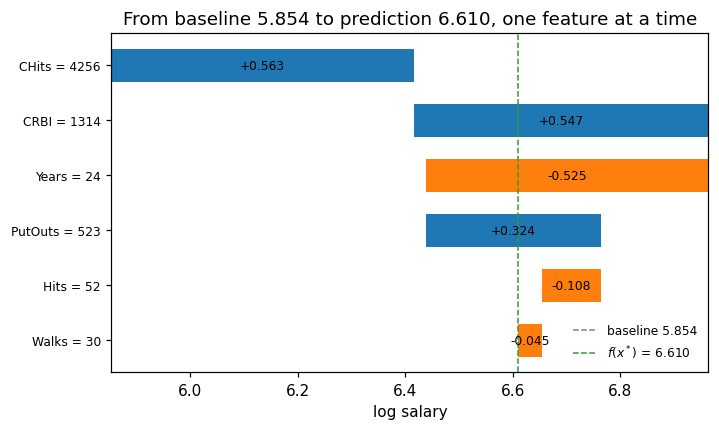

salary factors e^phi: {'CHits': 1.76, 'CRBI': 1.73, 'Years': 0.59, 'PutOuts': 1.38, 'Hits': 0.9, 'Walks': 0.96}
all together: e^0.756 = 2.13 x the baseline salary


In [8]:
order = np.argsort(np.abs(phi_star))[::-1]
vals, labels = phi_star[order], [f'{FEATS[j]} = {x_star[j]:.0f}' for j in order]
lefts = base + np.concatenate(([0.0], np.cumsum(vals)[:-1]))
ypos = np.arange(p)[::-1]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(ypos, vals, left=lefts, color=['C0' if v > 0 else 'C1' for v in vals], height=0.6)
for yp, lf, vv in zip(ypos, lefts, vals):
    ax.annotate(f'{vv:+.3f}', (lf + vv/2, yp), ha='center', va='center', fontsize=8)
ax.axvline(base, color='grey', ls='--', lw=1, label=f'baseline {base:.3f}')
ax.axvline(fx, color='C2', ls='--', lw=1, label=f'$f(x^*)$ = {fx:.3f}')
ax.set(yticks=ypos, xlabel='log salary',
       title='From baseline 5.854 to prediction 6.610, one feature at a time')
ax.set_yticklabels(labels, fontsize=8)
ax.legend(frameon=False, fontsize=8, loc='lower right')
plt.show()

# The same decomposition, read multiplicatively (log-scale attributions).
print('salary factors e^phi:', {FEATS[j]: round(float(np.exp(phi_star[j])), 2) for j in order})
print(f'all together: e^{phi_star.sum():.3f} = {np.exp(phi_star.sum()):.2f} x the baseline salary')

**Reading the output.** The model prices this player at $e^{0.756} = 2.13$ times the baseline: the record career totals multiply the salary by $1.76$ (`CHits`) and $1.73$ (`CRBI`), while the 24 seasons *divide* it by $1/0.59$. Because the model predicts *log* salary, attributions are additive in logs — i.e. multiplicative in dollars. Always state the output scale before presenting.

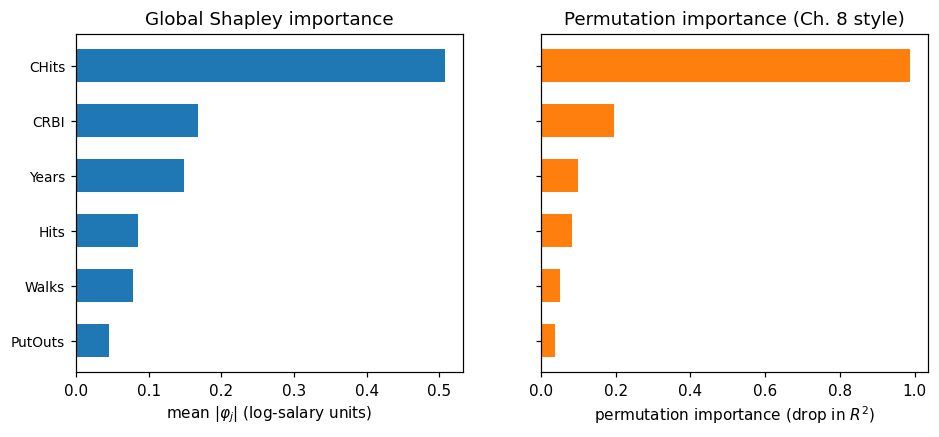

mean|phi| CHits = 0.508   perm importance CHits = 0.987   r(CHits, CRBI) = 0.947


In [9]:
# Global view: mean |phi_j| across all players vs Ch. 8's permutation importance.
from sklearn.inspection import permutation_importance

gimp = np.abs(PHI).mean(axis=0)
perm = permutation_importance(f, X, y, n_repeats=20, random_state=2024)
order = np.argsort(gimp)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ypos = np.arange(p)
axes[0].barh(ypos, gimp[order], color='C0', height=0.6)
axes[0].set(yticks=ypos, xlabel=r'mean $|\varphi_j|$ (log-salary units)',
            title='Global Shapley importance')
axes[0].set_yticklabels([FEATS[j] for j in order], fontsize=9)
axes[1].barh(ypos, perm.importances_mean[order], color='C1', height=0.6)
axes[1].set(xlabel='permutation importance (drop in $R^2$)',
            title='Permutation importance (Ch. 8 style)')
plt.show()

print(f'mean|phi| CHits = {gimp[FEATS.index("CHits")]:.3f}   '
      f'perm importance CHits = {perm.importances_mean[FEATS.index("CHits")]:.3f}   '
      f'r(CHits, CRBI) = {np.corrcoef(X[:, 1], X[:, 2])[0, 1]:.3f}')

**Reading the output.** Both rankings agree — `CHits` dominates — but the numbers answer different questions: mean $|\varphi_j| = 0.508$ is an average *contribution in log-salary units*; permutation importance $= 0.987$ is the *drop in $R^2$* when the feature is scrambled. Under correlation they can diverge: permuting `CHits` also destroys the information it shares with `CRBI` ($r = 0.947$), inflating its apparent solo importance.

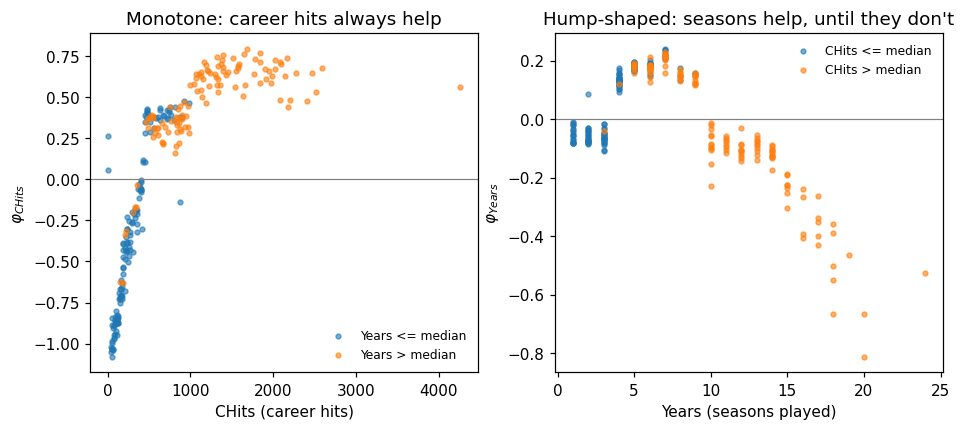

phi_CHits: mean -0.70 below 250 career hits,  +0.63 above 1000
phi_Years: mean +0.19 in seasons 5-7,  -0.45 beyond 15


In [10]:
# Dependence view: how each attribution varies with its own feature value.
chits, years = X[:, FEATS.index('CHits')], X[:, FEATS.index('Years')]
phi_ch, phi_yr = PHI[:, FEATS.index('CHits')], PHI[:, FEATS.index('Years')]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
hi = years > np.median(years)
axes[0].scatter(chits[~hi], phi_ch[~hi], s=10, alpha=0.6, color='C0', label='Years <= median')
axes[0].scatter(chits[hi], phi_ch[hi], s=10, alpha=0.6, color='C1', label='Years > median')
axes[0].axhline(0, color='grey', lw=0.8)
axes[0].set(xlabel='CHits (career hits)', ylabel=r'$\varphi_{CHits}$',
            title='Monotone: career hits always help')
axes[0].legend(frameon=False, fontsize=8)
hi = chits > np.median(chits)
axes[1].scatter(years[~hi], phi_yr[~hi], s=10, alpha=0.6, color='C0', label='CHits <= median')
axes[1].scatter(years[hi], phi_yr[hi], s=10, alpha=0.6, color='C1', label='CHits > median')
axes[1].axhline(0, color='grey', lw=0.8)
axes[1].set(xlabel='Years (seasons played)', ylabel=r'$\varphi_{Years}$',
            title="Hump-shaped: seasons help, until they don't")
axes[1].legend(frameon=False, fontsize=8)
plt.show()

print(f'phi_CHits: mean {phi_ch[chits < 250].mean():+.2f} below 250 career hits,'
      f'  {phi_ch[chits > 1000].mean():+.2f} above 1000')
print(f'phi_Years: mean {phi_yr[(years >= 5) & (years <= 7)].mean():+.2f} in seasons 5-7,'
      f'  {phi_yr[years > 15].mean():+.2f} beyond 15')

**Reading the output.** $\varphi_{\texttt{CHits}}$ rises monotonically — career volume always pays. $\varphi_{\texttt{Years}}$ is hump-shaped: $+0.19$ around seasons 5–7, $-0.45$ beyond 15 — *given* career totals, extra seasons mean less production per season. Vertical spread at a fixed $x$-value is the fingerprint of interactions.

## 6. Pitfalls

**Pitfall 1 — correlated features put the model off-manifold.** Marginal sampling pins $x_1$ and draws $x_2$ from the background, *ignoring* their correlation: with $\rho = 0.95$ most evaluation points sit outside the data ridge. In `Hitters`, $r_{\texttt{CHits},\texttt{CRBI}} = 0.947$, so $v(S)$ averages over impossible careers — like 4,256 hits with 3 RBI.

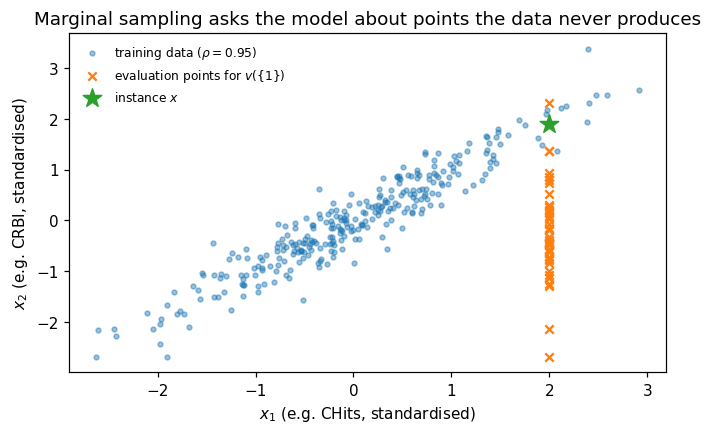

In [11]:
# Seeded illustration: two standardised features with rho = 0.95.
rng = np.random.default_rng(2024)
Z = rng.multivariate_normal([0, 0], [[1, 0.95], [0.95, 1]], size=300)
x_inst = np.array([2.0, 1.9])
bg2 = Z[rng.choice(300, 40, replace=False)]
mixed = np.column_stack([np.full(40, x_inst[0]), bg2[:, 1]])   # evaluating v({1})

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(Z[:, 0], Z[:, 1], s=10, alpha=0.45, color='C0', label=r'training data ($\rho=0.95$)')
ax.scatter(mixed[:, 0], mixed[:, 1], marker='x', s=30, color='C1',
           label=r'evaluation points for $v(\{1\})$')
ax.scatter(*x_inst, marker='*', s=160, color='C2', zorder=5, label='instance $x$')
ax.set(xlabel='$x_1$ (e.g. CHits, standardised)', ylabel='$x_2$ (e.g. CRBI, standardised)',
       title='Marginal sampling asks the model about points the data never produces')
ax.legend(frameon=False, fontsize=8, loc='upper left')
plt.show()

In [12]:
# Pitfall 3 — attributions move when the model is retrained.
# Two stochastic refits, same data, same accuracy: watch the CHits/CRBI split move.
for seed in (1, 2):
    g = GradientBoostingRegressor(random_state=seed, subsample=0.7).fit(X, y)
    bse = g.predict(bg).mean()
    def v2(S, x, g=g, bse=bse):
        Z = bg.copy()
        if S: Z[:, list(S)] = x[list(S)]
        return g.predict(Z).mean() - bse
    phi2 = np.zeros(p)
    for j in range(p):
        rest = [k for k in range(p) if k != j]
        for r in range(p):
            for S in itertools.combinations(rest, r):
                phi2[j] += w[r] * (v2(S + (j,), x_star) - v2(S, x_star))
    ch, cr = phi2[FEATS.index('CHits')], phi2[FEATS.index('CRBI')]
    print(f'refit seed {seed}:  train R^2 {g.score(X, y):.3f}   '
          f'phi_CHits {ch:+.3f}   phi_CRBI {cr:+.3f}   pair sum {ch + cr:+.3f}')

refit seed 1:  train R^2 0.964   phi_CHits +0.702   phi_CRBI +0.521   pair sum +1.223


refit seed 2:  train R^2 0.963   phi_CHits +0.600   phi_CRBI +0.545   pair sum +1.146


**Reading the output.** Two equally accurate models ($R^2 \approx 0.96$), and $\varphi_{\texttt{CHits}}$ swings by $0.10$ (about $15\%$) between them — while the *pair's sum* barely moves. Correlated features are interchangeable to the fit, so the fit chooses arbitrarily and the attribution follows. Robust practice: report the **group attribution** for a correlated cluster, and freeze model + background + seed per reporting period. And remember Pitfall 2 throughout: an explanation describes the *model*, not the world — $\varphi_j$ is not a causal effect.

## Lecture exercises — worked Python solutions

These are the **[Python]-tagged exercises from the lecture slides**, solved step by step; run them cell by cell and compare with the slide solutions. Data loads through the `load()` helper defined in the Setup cell, so every cell works locally and on Colab.

### Extended Exercise A2.1 — Monte-Carlo Shapley from scratch [Python]

**Task (from the slides).** Implement permutation sampling for the veteran instance $x^\ast$ (row 188) and quantify its accuracy against the exact values:
1. write `mc_shapley(x, m, rng)`: sample $m$ orderings with `rng.permutation(p)`; for each, walk through the features, awarding each its change in $v$ (start the walk at $v(\varnothing) = 0$);
2. run it with $m = 100$ and `default_rng(2024)`; tabulate $\hat\varphi_j$ against the exact $\varphi_j$ and report the mean and maximum absolute error;
3. estimate the error at $m \in \{25, 100, 400\}$ (average over 10 repeats) — does quadrupling $m$ halve the error?
4. compare total model calls of your $m = 100$ run against exact enumeration at $p = 6$; which wins here, and when does that flip?

In [13]:
# (1)-(2): mc_shapley was defined in Section 4 — rerun the m = 100 estimate.
rng = np.random.default_rng(2024)
est = mc_shapley(x_star, 100, rng)
print(pd.DataFrame({'mc (m=100)': est, 'exact': phi_star}, index=FEATS).round(4).to_string())
err = np.abs(est - phi_star)
print(f'\nmean abs error {err.mean():.3f},  max {err.max():.3f}')
# Expected: mean 0.012, max 0.027 (on CRBI); every sign and the ranking correct.

# (3): the convergence study of Section 4 already covers m = 25, 100, 400:
for m, e in zip(ms, mean_err):
    if m in (25, 100, 400):
        print(f'm = {m:3d}: mean abs error {e:.4f}')
# Expected: 0.0153 -> 0.0079 -> 0.0035 — quadrupling m roughly halves the error.

         mc (m=100)   exact
Years       -0.5164 -0.5245
CHits        0.5408  0.5626
CRBI         0.5741  0.5474
Walks       -0.0496 -0.0452
Hits        -0.1071 -0.1084
PutOuts      0.3145  0.3244

mean abs error 0.012,  max 0.027
m =  25: mean abs error 0.0153
m = 100: mean abs error 0.0079
m = 400: mean abs error 0.0035


**(4) Cost accounting.** Exact at $p = 6$: $2^p \cdot B = 64 \times 100 = 6{,}400$ model calls. MC at $m = 100$: $m \cdot p \cdot B = 100 \times 6 \times 100 = 60{,}000$ calls — *nine times more*, for an approximate answer. At $p = 6$ exact enumeration wins outright. The flip is fast: exact doubles with every added feature ($2^{20} \cdot B \approx 10^8$ calls at $p = 20$) while the MC budget grows only linearly in $p$ — at $p = 20$ the same $m = 100$ costs $200{,}000$ calls, now $500\times$ cheaper than exact. Enumerate while you can ($p \lesssim 15$); sample when you must; and for tree ensembles, TreeSHAP gives exactness at neither price.

### Exercise A2.5 — Explain another player [Python]

**Task (from the slides).** Row 0 of the cleaned data is a 14-season veteran: `Years` $= 14$, `CHits` $= 835$, `CRBI` $= 414$, `Walks` $= 39$, `Hits` $= 81$, `PutOuts` $= 632$; actual salary \$475k. With the fitted model and `exact_shapley`:
1. compute $f(x)$ and the six exact attributions $\varphi_j$;
2. verify efficiency: $\sum_j \varphi_j = f(x) - \varphi_0$;
3. name the largest positive and largest negative contribution and restate each as a multiplicative salary factor $e^{\varphi_j}$.

In [14]:
# (1)-(2) ---------------------------------------------------------------
x0 = X[0]
print('x0 =', dict(zip(FEATS, x0.astype(int))), f'  actual salary ${Hitters["Salary"][0]:.0f}k')
phi0_vec = exact_shapley(x0)
f0 = f.predict(x0.reshape(1, -1))[0]
print(pd.Series(phi0_vec, index=FEATS).round(3).sort_values(ascending=False).to_string())
print(f'\nf(x0) = {f0:.3f} log-$ (= ${np.exp(f0):.0f}k)')
print(f'efficiency: sum phi_j = {phi0_vec.sum():.3f}   f(x0) - phi_0 = {f0 - base:.3f}')

# (3) --------------------------------------------------------------------
jmax, jmin = np.argmax(phi0_vec), np.argmin(phi0_vec)
print(f'largest positive: {FEATS[jmax]} {phi0_vec[jmax]:+.3f}  -> factor e^phi = {np.exp(phi0_vec[jmax]):.2f}')
print(f'largest negative: {FEATS[jmin]} {phi0_vec[jmin]:+.3f}  -> factor e^phi = {np.exp(phi0_vec[jmin]):.2f}')

x0 = {'Years': np.int64(14), 'CHits': np.int64(835), 'CRBI': np.int64(414), 'Walks': np.int64(39), 'Hits': np.int64(81), 'PutOuts': np.int64(632)}   actual salary $475k
CHits      0.287
PutOuts    0.176
CRBI       0.112
Walks     -0.037
Hits      -0.100
Years     -0.125

f(x0) = 6.167 log-$ (= $477k)
efficiency: sum phi_j = 0.313   f(x0) - phi_0 = 0.313
largest positive: CHits +0.287  -> factor e^phi = 1.33
largest negative: Years -0.125  -> factor e^phi = 0.88


**Reading the output.** $f(x_0) = 6.167 \approx \$477$k against an actual \$475k — the model is nearly on the money here, and $\sum_j \varphi_j = 0.313 = 6.167 - 5.854$ to machine precision. A solid career record raises the predicted salary by a third (`CHits` $+0.287$, factor $1.33$); the 14 seasons apply the same late-career discount we saw in the dependence plot ($-0.125$, factor $0.88$) — only milder than the record-holder's $-0.525$ at 24 seasons. One warning from the slides: never compare $\varphi_j$ across explanations computed with *different backgrounds* — one report, one background.

## 7. Exercises

1. Re-run Section 2 with a different background (`rng.choice` with another seed, or $B = 20$). How much do $\varphi_0$ and the veteran's attributions move? What does that say about reporting requirements?
2. Add `AtBat` as a seventh feature and refit. How long does exact enumeration take now, and does the `CHits`/`CRBI`/`AtBat` split behave like the correlated-cluster warning of Section 6?
3. In Section 4, track the standard error *across orderings* for $m = 100$ instead of repeating the whole run. Does it give an honest error bar?
4. Compute group attributions $\varphi_{\texttt{CHits}} + \varphi_{\texttt{CRBI}}$ for the two refits of Section 6 and for five more seeds. Is the group sum stable enough for a reason-code pipeline?